# Static vs Oscillating Photon Emission

This notebook compares three cases:

1. The compact field-diagonalized reduced model at static `E_z = 0 V/cm`
2. The interpolated effective model at static `E_z = 0 V/cm` in the common `0 V/cm` basis
3. The interpolated effective model with an oscillating field between `0` and `50 V/cm` at `100 kHz`

The effective model uses a patch atlas in the `0 V/cm` basis with low-field refinement.

In [1]:
from __future__ import annotations

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid

import effective_hamiltonian_runtime as ehr

In [2]:
B_FIELD = np.array([0.0, 0.0, 1e-5], dtype=np.float64)
RABI_RATE = 2.0 * np.pi * 1e6
DETUNING = 0.0

OSCILLATION_FREQUENCY_HZ = 100e3
OSCILLATION_FIELD_MAX_VCM = 50.0

PATCH_POINTS_VCM = [0.0, 5.0, 10.0, 20.0, 30.0, 40.0, 50.0]
MASTER_FIELD_VCM = 0.0

T_EVAL = np.linspace(0.0, 50e-6, 1001)
T_SPAN = (float(T_EVAL[0]), float(T_EVAL[-1]))


def oscillating_field_vcm(t: float) -> float:
    return (
        0.5
        * OSCILLATION_FIELD_MAX_VCM
        * (1.0 - np.cos(2.0 * np.pi * OSCILLATION_FREQUENCY_HZ * t))
    )


def dynamic_scattering_rate(
    model, rho_t: np.ndarray, t_eval: np.ndarray, electric_field, magnetic_field
) -> np.ndarray:
    rates = []
    for t, rho in zip(t_eval, rho_t):
        bundle = model.effective_bundle(electric_field(float(t)), magnetic_field)
        rates.append(np.real(np.trace(rho @ bundle.jump_rate_operator())))
    return np.asarray(rates, dtype=np.float64)


def cumulative_photons(rate: np.ndarray, t_eval: np.ndarray) -> np.ndarray:
    return cumulative_trapezoid(rate, t_eval, initial=0.0)

In [ ]:
from centrex_tlf import states, hamiltonian

ham = hamiltonian.generate_uncoupled_hamiltonian_X(
    states.generate_uncoupled_states_ground([0, 1, 2, 3])
)
ham_func = np.

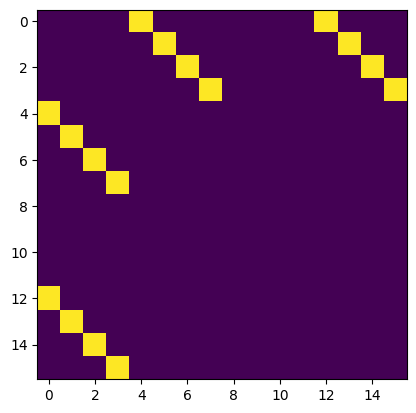

In [39]:
plt.imshow(np.abs(ham.HSx)[:16, :16])

## Build The Interpolated Effective Model

In [3]:
interpolated_model = ehr.prepare_interpolated_effective_model(
    field_points=PATCH_POINTS_VCM,
    master_field=MASTER_FIELD_VCM,
    magnetic_field=B_FIELD,
)

## Static Compact Reference At 0 V/cm

In [5]:
_, static_compact_bundle = ehr.build_compact_reference_decomposed_bundle(
    electric_field=(0.0, 0.0, 0.0),
    magnetic_field=B_FIELD,
)

rho0_static_compact = np.zeros(
    (
        static_compact_bundle.h_internal.shape[0],
        static_compact_bundle.h_internal.shape[0],
    ),
    dtype=np.complex128,
)
rho0_static_compact[0, 0] = 1.0

solution_static_compact = ehr.solve_static_density_matrix_bundle(
    static_compact_bundle,
    rho0=rho0_static_compact,
    t_span=T_SPAN,
    rabi_rate=RABI_RATE,
    detuning=DETUNING,
    t_eval=T_EVAL,
)

rho_t_static_compact = ehr.solution_to_density_matrices(
    solution_static_compact,
    static_compact_bundle.h_internal.shape[0],
)
rate_static_compact = ehr.scattering_signal(
    rho_t_static_compact,
    static_compact_bundle.jump_rate_operator(),
)
photons_static_compact = ehr.integrated_scattering_probability(
    T_EVAL,
    rho_t_static_compact,
    static_compact_bundle.jump_rate_operator(),
)


## Static Effective Model At 0 V/cm

In [6]:
rho0_static_effective = ehr.default_effective_density_matrix(interpolated_model)
solution_static_effective = ehr.solve_static_effective_model(
    interpolated_model,
    electric_field=0.0,
    magnetic_field=B_FIELD,
    rho0=rho0_static_effective,
    t_span=T_SPAN,
    rabi_rate=RABI_RATE,
    detuning=DETUNING,
    t_eval=T_EVAL,
)

rho_t_static_effective = ehr.solution_to_density_matrices(
    solution_static_effective,
    interpolated_model.n_effective_states,
)
static_effective_bundle = interpolated_model.effective_bundle(0.0, B_FIELD)
rate_static_effective = ehr.scattering_signal(
    rho_t_static_effective,
    static_effective_bundle.jump_rate_operator(),
)
photons_static_effective = ehr.integrated_scattering_probability(
    T_EVAL,
    rho_t_static_effective,
    static_effective_bundle.jump_rate_operator(),
)


## Oscillating Effective Model From 0 To 50 V/cm

In [7]:
solution_oscillating = ehr.solve_effective_model(
    interpolated_model,
    electric_field=oscillating_field_vcm,
    magnetic_field=B_FIELD,
    t_span=T_SPAN,
    rabi_rate=RABI_RATE,
    detuning=DETUNING,
    t_eval=T_EVAL,
)

rho_t_oscillating = ehr.solution_to_density_matrices(
    solution_oscillating,
    interpolated_model.n_effective_states,
)
rate_oscillating = dynamic_scattering_rate(
    interpolated_model,
    rho_t_oscillating,
    T_EVAL,
    oscillating_field_vcm,
    B_FIELD,
)
photons_oscillating = float(np.trapezoid(rate_oscillating, x=T_EVAL))

## Summary

In [8]:
summary = {
    "photons_static_compact": float(photons_static_compact),
    "photons_static_effective": float(photons_static_effective),
    "photons_oscillating_effective": float(photons_oscillating),
    "static_effective_minus_compact": float(
        photons_static_effective - photons_static_compact
    ),
    "static_effective_vs_compact_rel": float(
        (photons_static_effective - photons_static_compact) / photons_static_compact
    ),
    "oscillating_minus_static_effective": float(
        photons_oscillating - photons_static_effective
    ),
    "oscillating_vs_static_effective_rel": float(
        (photons_oscillating - photons_static_effective) / photons_static_effective
    ),
    "oscillating_minus_static_compact": float(
        photons_oscillating - photons_static_compact
    ),
    "oscillating_vs_static_compact_rel": float(
        (photons_oscillating - photons_static_compact) / photons_static_compact
    ),
}
summary

{'photons_static_compact': 2.3895395607054724,
 'photons_static_effective': 1.9452830125097855,
 'photons_oscillating_effective': 1.9261996507615358,
 'static_effective_minus_compact': -0.44425654819568683,
 'static_effective_vs_compact_rel': -0.18591721832156125,
 'oscillating_minus_static_effective': -0.01908336174824976,
 'oscillating_vs_static_effective_rel': -0.009810069601969427,
 'oscillating_minus_static_compact': -0.4633399099439366,
 'oscillating_vs_static_compact_rel': -0.1939034270715916}

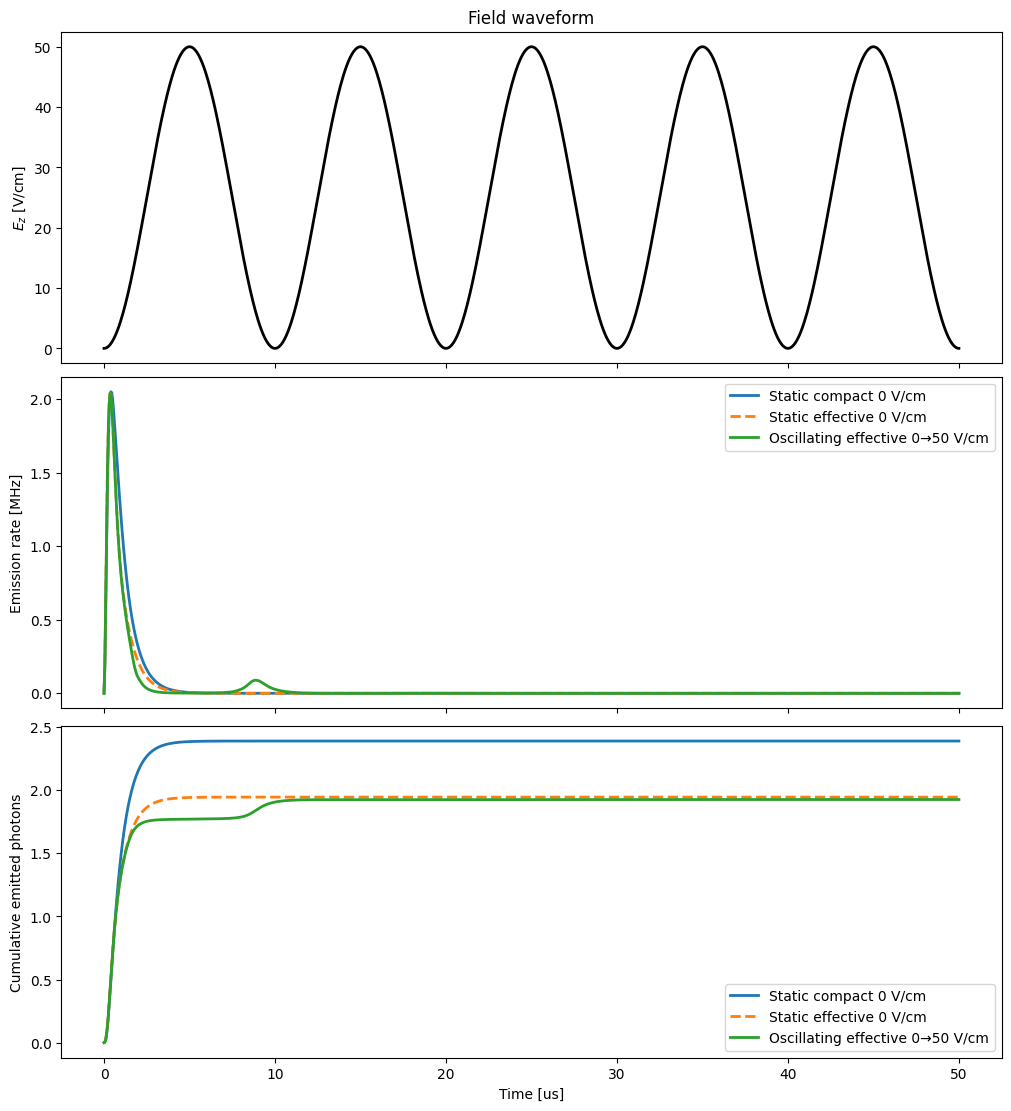

In [9]:
field_trace = np.array(
    [oscillating_field_vcm(float(t)) for t in T_EVAL], dtype=np.float64
)

cum_static_compact = cumulative_photons(rate_static_compact, T_EVAL)
cum_static_effective = cumulative_photons(rate_static_effective, T_EVAL)
cum_oscillating = cumulative_photons(rate_oscillating, T_EVAL)

fig, axes = plt.subplots(3, 1, figsize=(10, 11), sharex=True, constrained_layout=True)

axes[0].plot(T_EVAL * 1e6, field_trace, color="black", lw=2)
axes[0].set_ylabel(r"$E_z$ [V/cm]")
axes[0].set_title("Field waveform")

axes[1].plot(
    T_EVAL * 1e6, rate_static_compact / 1e6, label="Static compact 0 V/cm", lw=2
)
axes[1].plot(
    T_EVAL * 1e6,
    rate_static_effective / 1e6,
    label="Static effective 0 V/cm",
    lw=2,
    ls="--",
)
axes[1].plot(
    T_EVAL * 1e6, rate_oscillating / 1e6, label="Oscillating effective 0→50 V/cm", lw=2
)
axes[1].set_ylabel("Emission rate [MHz]")
axes[1].legend()

axes[2].plot(T_EVAL * 1e6, cum_static_compact, label="Static compact 0 V/cm", lw=2)
axes[2].plot(
    T_EVAL * 1e6, cum_static_effective, label="Static effective 0 V/cm", lw=2, ls="--"
)
axes[2].plot(
    T_EVAL * 1e6, cum_oscillating, label="Oscillating effective 0→50 V/cm", lw=2
)
axes[2].set_xlabel("Time [us]")
axes[2].set_ylabel("Cumulative emitted photons")
axes[2].legend()

plt.show()